In [45]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import random
from dreal import *
import matplotlib.patches as patches
from matplotlib import cm

In [46]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import random
from dreal import *
import matplotlib.patches as patches
from matplotlib import cm

In [47]:
import sys
import os

sys.path.append(os.path.join(os.path.dirname(os.path.abspath("__file__")), ".."))

from Neural_Density_Training.Models import (
    Polynomial_net,
    Polynomial_net_bias_zero,
    Numerator_polynomial_net,
    GammaFunctionNet,
)
from Neural_Density_Training.loss import (
    stability_loss,
    invariance_loss,
    safety_loss,
)
from Neural_Density_Training.falsifier import checkSMTconstraints, AddCounterexamples
from Neural_Density_Training.extract_model import SymbolicNN, activSymbolicNN
from Neural_Density_Training.plotter import (
    plot_contour_density,
    plot_contour_mixed_density,
)

In [48]:

torch.cuda.empty_cache()
torch.manual_seed(17)
random.seed()

In [49]:

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Pre-allocate numerical_x
numerical_x = torch.Tensor(500, 2).uniform_(-6, 6).float().to(device)


Using device: cpu


# Van der pol oscillator

The contorlled version of van der pol oscillator is:
\begin{align}
    \dot{x}_1&=x_2\\
    \dot{x}_2&=\mu(1-x_1^2)x_2-x_1+u
\end{align}

In [50]:
def dynamics(x, damping_factor):
    def f(x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
        val = torch.stack([
            x[:,1],
            damping_factor * (1-x[:,0]**2) * x[:,1] - x[:,0]
        ], dim=1)

        return val.squeeze(0) if val.shape[0] == 1 else val

    def g(x):
        """Vectorized g(x) - handles batched input"""
        if x.dim() == 1:
            x = x.unsqueeze(0)
        
        val = torch.stack([
            torch.zeros_like(x[:, 0]),
            torch.ones_like(x[:, 0])
        ], dim=1)
        
        return val.squeeze(0) if val.shape[0] == 1 else val


    def div_f(x):
        """Vectorized divergence of f - handles batched input: div(f)= damping * (1-x[0]^2)"""
        if x.dim() == 1:
            return damping_factor * (1 - x[0]**2)
        else:
            return damping_factor * ( 1- x[:, 0]**2)
        

    def div_g(x):
        """Vectorized divergence of g"""
        if x.dim() == 1:
            return torch.tensor(0.0, device=device)
        else:
            return torch.zeros(x.shape[0], device=device)
        
    return f, g, div_f, div_g

In [51]:

def candidate_constraint_learnt(vars, a_fun, b_fun, c_fun,damping_factor):
    """Construct candidate constraints for the learnt functions"""
    a_sym = activSymbolicNN(a_fun).forward_symbolic(vars)[0]
    b_sym = SymbolicNN(b_fun).forward_symbolic(vars)
    c_sym = SymbolicNN(c_fun).forward_symbolic(vars)[0]
    
    b_sym = sum([bi**2 for bi in b_sym])
    
    # Symbolic dynamics for inverted pendulum
    f_val = [
        vars[1],
        damping_factor * (1 - vars[0]**2) * vars[1] - vars[0]
    ]
    g_val = [
        0.0 * vars[0],
        1.0 
    ]
    
    f_div = damping_factor * (1 - vars[0]**2)
    g_div = 0
    
    grad_a = [a_sym.Differentiate(vars[i]) for i in range(len(vars))]
    grad_c = [c_sym.Differentiate(vars[i]) for i in range(len(vars))]
    grad_b = [b_sym.Differentiate(vars[i]) for i in range(len(vars))]
    
    constraint1 = (a_sym * f_div + g_div * c_sym + 
                   sum([grad_a[i] * f_val[i] for i in range(len(f_val))]) + 
                   sum([grad_c[i] * g_val[i] for i in range(len(g_val))]))
    
    scaled_vars = [2 * var_i for var_i in vars]
    constraint2 = [scaled_vars[i] + grad_b[i] for i in range(len(vars))]
    constraint2 = sum([constraint2[i] * (f_val[i] * a_sym + g_val[i] * c_sym) 
                      for i in range(len(f_val))])
    
    constraint = constraint1 - constraint2
    return a_sym, constraint

In [52]:
def train_density(
    x,                          # initial sample tensor  [N, state_dim]
    f,                          # dynamics callable
    g,                          # control matrix callable
    div_f,                      # divergence of f callable
    div_g,                      # divergence of g callable
    damping_factor,
    device,
    # --- training ---
    epochs          = 2000,
    lr              = 1e-2,
    loss_threshold  = 5e-4,
    # --- SMT verification ---
    ball_lb         = 0.05,
    ball_ub         = 6.0,
    check_interval  = 10,
    n_counterex     = 100,
):
    
    # Instantiate neural networks for a, b, c, gamma
    a_net = Numerator_polynomial_net(layers=2, input_dim=2, hidden_dim=8, output_dim=1).to(device)
    b_net = Polynomial_net_bias_zero(layers=2, input_dim=2, hidden_dim=8, output_dim=4).to(device)
    c_net = Polynomial_net(layers=2, input_dim=2, hidden_dim=12, output_dim=1).to(device)
    gamma_net = GammaFunctionNet(input_dim=2,output_dim=1).to(device)

    f, g, div_f, div_g = dynamics(x, damping_factor=damping_factor)
    # Loss and Optimizer
    criterion = stability_loss(f=f,g=g,div_f=div_f,div_g=div_g)

    optimizer = torch.optim.Adam(list(a_net.parameters()) +
                                    list(b_net.parameters()) + 
                                    list(c_net.parameters()) + 
                                    list(gamma_net.parameters()), lr=lr)
    
    # dReal Configuration
    config = Config()
    config.use_polytope_in_forall = True
    config.use_local_optimization = True
    config.precision = 1e-5   

    # CEGIS Loop
    loss_history = []
    valid = False 
    print("=" * 60)
    print("Training density function with SMT-CEGIS verification")
    print(f"  Initial dataset size: {x.shape[0]}")
    print("=" * 60)    

    while not valid:
        for epoch in range(epochs):
            optimizer.zero_grad()
            loss = criterion(x, a_net, b_net, c_net, gamma_net)         
            loss_history.append(loss.item())
            loss.backward()
            optimizer.step()

            
            # ---------- early-exit on convergence ----------
            if loss.item() < loss_threshold:
                print(f"  [Epoch {epoch}] Loss {loss.item():.6f} < threshold to checking SMT...")
                valid = True
                break

            # ---------- periodic progress print ------------
            if epoch % 50 == 0:
                print(
                    f"  Epoch {epoch:>5}/{epochs} | "
                    f"Loss: {loss.item():.6f} | "
                    f"Dataset: {x.shape[0]}"
                )            
 
            # ---------- SMT counterexample check -----------
            if epoch % check_interval == 0 and epoch > 0:
                vars_sym = [Variable("x1"), Variable("x2")]
                try:
                    a_sym, div_sym = candidate_constraint_learnt(
                        vars_sym, a_net, b_net, c_net, damping_factor
                    )
                    CE = checkSMTconstraints(
                        vars_sym, a_sym, div_sym, ball_lb, ball_ub, config
                    )
 
                    if CE:
                        before = x.shape[0]
                        x, _ = AddCounterexamples(x, CE, n_counterex, device)
                        after = x.shape[0]
                        print(
                            f"  [Epoch {epoch}] CE found → "
                            f"dataset {before} → {after} (+{after - before})"
                        )
                    else:
                        valid = True
                        print(f"  [Epoch {epoch}] SMT satisfied — no counterexample found ✓")
                        break
 
                except Exception as e:
                    print(f"  [Epoch {epoch}] SMT check failed: {e}")
                    continue
 
    # ------------------------------------------------------------------
    # 5. Final summary
    # ------------------------------------------------------------------
    test_point = torch.zeros(1, 2, dtype=torch.float32, device=device)
    margin     = gamma_net(test_point).item()
 
    print("\n" + "=" * 60)
    print("Training complete")
    print(f"  Final loss     : {loss_history[-1]:.6f}")
    print(f"  Learned margin : {margin:.6f}")
    print(f"  Final dataset  : {x.shape[0]}")
    print("=" * 60)
 
    return loss_history, a_net, b_net, c_net, gamma_net
 

In [53]:
damping_factor_list = [0.1,0.5,1,2]

In [54]:
print("Starting training...")
loss_history = []
a_net = []
b_net = []
c_net = []

for damping_factor in damping_factor_list:

    f, g, div_f, div_g = dynamics(numerical_x, damping_factor=damping_factor)
    print(f"\nTraining for damping factor: {damping_factor}")
        
    loss_history1, a_net1, b_net1, c_net1, gamma_net1 = train_density(
        numerical_x, f, g, div_f, div_g,damping_factor, device,
        epochs=4000,
        lr=1e-4,
        loss_threshold=5e-4,
        ball_lb=0.05,
        ball_ub=6.0,
        check_interval=1000,
        n_counterex=100
    )

    loss_history.append(loss_history1)
    a_net.append(a_net1)
    b_net.append(b_net1)
    c_net.append(c_net1)
    

Starting training...

Training for damping factor: 0.1
Training density function with SMT-CEGIS verification
  Initial dataset size: 500
  Epoch     0/4000 | Loss: 1.892555 | Dataset: 500
  Epoch    50/4000 | Loss: 1.668982 | Dataset: 500
  Epoch   100/4000 | Loss: 1.464723 | Dataset: 500
  Epoch   150/4000 | Loss: 1.281793 | Dataset: 500
  Epoch   200/4000 | Loss: 1.119647 | Dataset: 500
  Epoch   250/4000 | Loss: 0.957592 | Dataset: 500
  Epoch   300/4000 | Loss: 0.799149 | Dataset: 500
  Epoch   350/4000 | Loss: 0.655900 | Dataset: 500
  Epoch   400/4000 | Loss: 0.524342 | Dataset: 500
  Epoch   450/4000 | Loss: 0.397598 | Dataset: 500
  Epoch   500/4000 | Loss: 0.284704 | Dataset: 500
  Epoch   550/4000 | Loss: 0.187865 | Dataset: 500
  Epoch   600/4000 | Loss: 0.109422 | Dataset: 500
  Epoch   650/4000 | Loss: 0.067253 | Dataset: 500
  Epoch   700/4000 | Loss: 0.049105 | Dataset: 500
  Epoch   750/4000 | Loss: 0.039029 | Dataset: 500
  Epoch   800/4000 | Loss: 0.032970 | Dataset: 

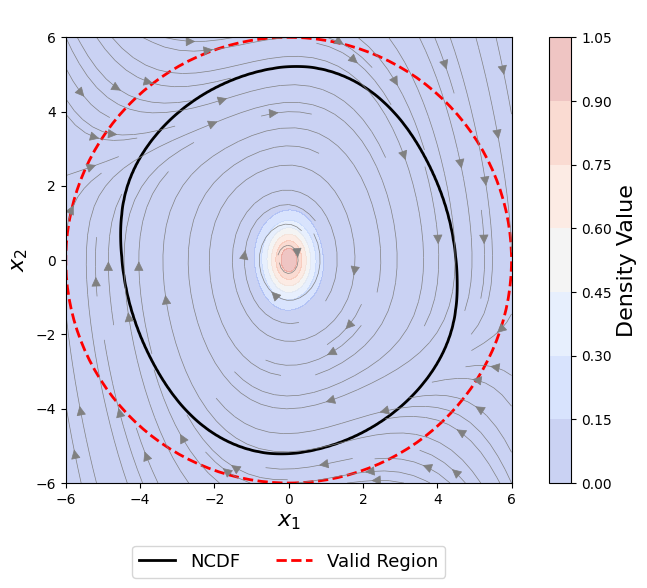

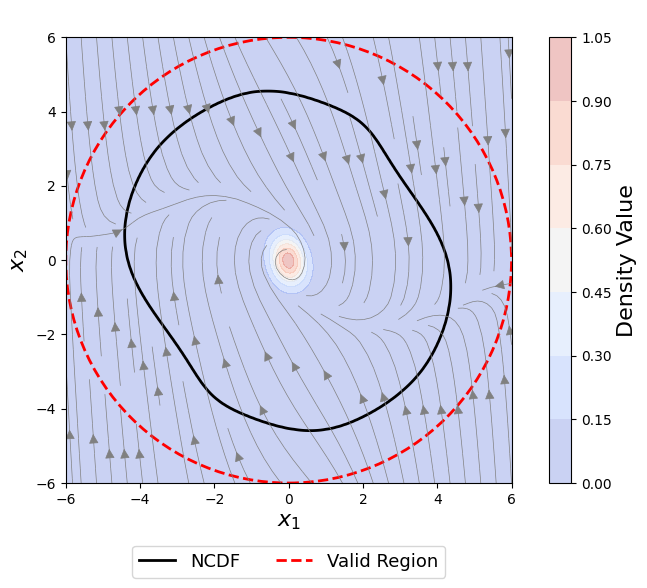

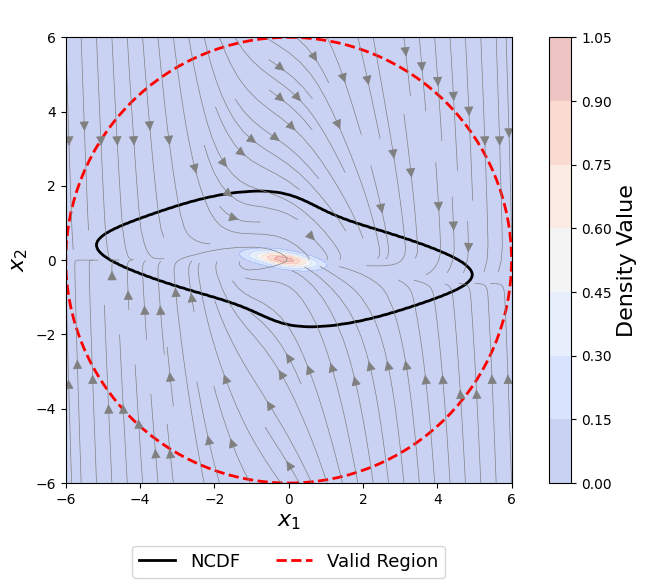

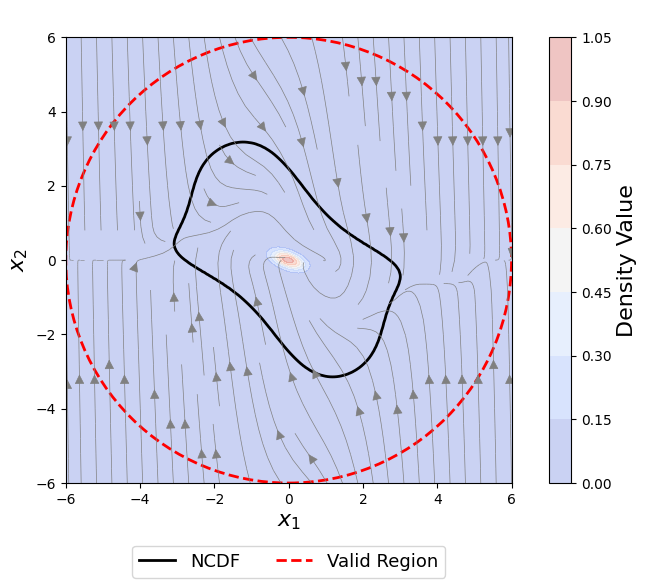

In [56]:
# plot for each damping factor

for damping_factor in damping_factor_list:
    index = damping_factor_list.index(damping_factor)
    a_net_i = a_net[index]
    b_net_i = b_net[index]
    c_net_i = c_net[index]
    f, g, div_f, div_g = dynamics(numerical_x, damping_factor=damping_factor)
    plot_contour_density(
    f,g,a_net_i,b_net_i,c_net_i,x_lim = [-6,6],
    y_lim = [-6,6],
    density_threshold = 1e-12,
    title =" ",
    x_axis_title = "$x_1$",
    y_axis_title = "$x_2$",
    device = device
)

